# Email Spam Classification using Scikit-Learn
This notebook demonstrates a Machine Learning approach to classify emails as either 'Spam' or 'Ham' (non-spam). We utilize natural language processing (NLP) techniques and various classification models to achieve high accuracy..

## 1. Importing Libraries
We use `pandas` for data manipulation and `sklearn` for text preprocessing, vectorization, and machine learning modeling..

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

## 2. Data Loading and Exploration
The dataset consists of labeled text messages. In this section, we load the data and inspect its structure, checking for any missing values or class imbalances..

In [2]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))



/kaggle/input/datasets/salmahafid/spam-email-dataset/emails.csv


In [3]:
path = '/kaggle/input/datasets/salmahafid/spam-email-dataset/emails.csv'
data = pd.read_csv(path)
data.head()

,text,spam
0,Subject: naturally irresistible your corporate...,1
1,Subject: the stock trading gunslinger fanny i...,1
2,Subject: unbelievable new homes made easy im ...,1
3,Subject: 4 color printing special request add...,1
4,"Subject: do not have money , get software cds ...",1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5728 entries, 0 to 5727
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    5728 non-null   object
 1   spam    5728 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 89.6+ KB


In [5]:
data.shape

(5728, 2)

In [6]:
data.isnull().sum()

text    0
spam    0
dtype: int64

In [7]:
data["text"]

0       Subject: naturally irresistible your corporate...
1       Subject: the stock trading gunslinger  fanny i...
2       Subject: unbelievable new homes made easy  im ...
3       Subject: 4 color printing special  request add...
4       Subject: do not have money , get software cds ...
                              ...                        
5723    Subject: re : research and development charges...
5724    Subject: re : receipts from visit  jim ,  than...
5725    Subject: re : enron case study update  wow ! a...
5726    Subject: re : interest  david ,  please , call...
5727    Subject: news : aurora 5 . 2 update  aurora ve...
Name: text, Length: 5728, dtype: object

## 3. Data Preprocessing
To prepare the text for machine learning models, we perform the following steps:
* Convert all text to **lowercase**.
* Remove **punctuation** and special characters.
* Filter out English **stopwords** that do not contribute to the predictive power of the model.

In [8]:
import string
from nltk.corpus import stopwords

stopwords_eng = set(stopwords.words('english'))

def clean(text):
    text = text.lower()
    text = text.translate(str.maketrans('', '', string.punctuation))
    word = text.split()
    word = [m for m in word if m not in stopwords_eng]
    return " ".join(word)

## 4. Vectorization and Data Splitting
Since models cannot process raw text, we convert the messages into numerical vectors using `CountVectorizer`. We then split the dataset into **training** and **testing** sets to evaluate our performance.

In [9]:
X1 = data["text"].apply(clean)
vect=CountVectorizer()
T=vect.fit_transform(X1)
matrice_sparce=T.toarray()
print(matrice_sparce)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [4 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [10]:
X_train,X_test,y_train,y_test=train_test_split(T,data["spam"],test_size=0.3,random_state=23,stratify=data['spam'])

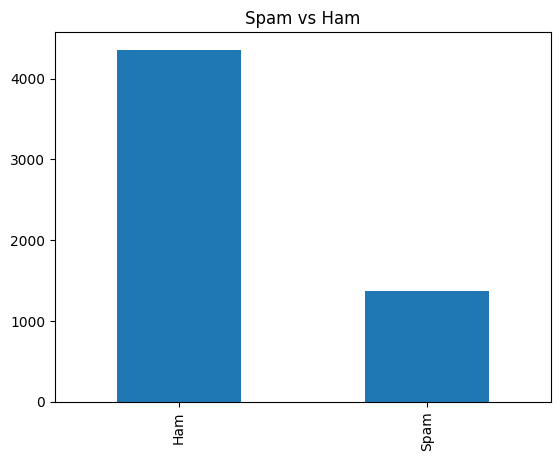

In [11]:
import matplotlib.pyplot as plt

data['spam'].map({0:'Ham',1:'Spam'}).value_counts().plot(kind='bar')
plt.title("Spam vs Ham")
plt.xlabel("")
plt.show()

In [12]:
data['length'] = data['text'].apply(len)

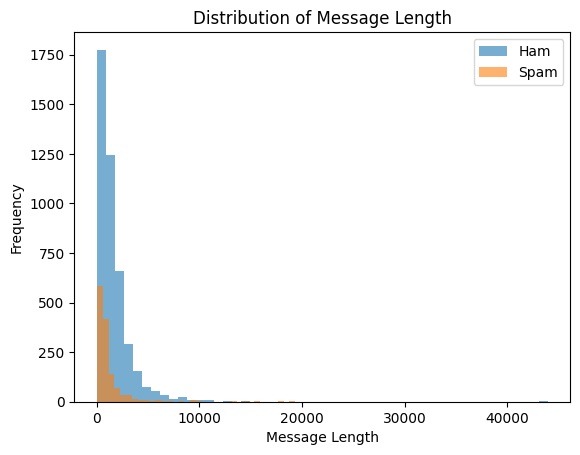

       count         mean          std   min     25%     50%      75%      max
spam                                                                          
0     4360.0  1631.918119  1959.664549  13.0  577.75  1122.0  2037.25  43952.0
1     1368.0  1317.257310  2271.372893  18.0  401.50   693.5  1250.25  28432.0


In [13]:
import matplotlib.pyplot as plt

spam = data[data['spam'] == 1]['length']
ham = data[data['spam'] == 0]['length']

plt.hist(ham, bins=50, alpha=0.6, label='Ham')
plt.hist(spam, bins=50, alpha=0.6, label='Spam')

plt.title("Distribution of Message Length")
plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.legend()

plt.show()
print(data.groupby('spam')['length'].describe())

## 5. Model Training and Evaluation
We train and compare several classification algorithms, including **Support Vector Classifier (SVC)** and **Naive Bayes**, to determine which one provides the highest accuracy for spam detection.

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, recall_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

def evaluer_modele(model, X_train, X_test, y_train, y_test, model_name="Modèle"):
    
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    
    accuracy = accuracy_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    
    print(f"===== {model_name} =====")
    print("Accuracy :", accuracy)
    print("Recall :", recall)
    
    
    print("\nClassification Report :")
    print(classification_report(y_test, y_pred))
    
    print("Confusion Matrix :\n")
    conf_matrix = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrix)
    disp.plot(cmap='bone_r')
    plt.title(model_name)
    plt.show()
    
    return accuracy, recall

===== Decision Tree =====
Accuracy : 0.9616055846422339
Recall : 0.9294403892944039

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1308
           1       0.91      0.93      0.92       411

    accuracy                           0.96      1719
   macro avg       0.94      0.95      0.95      1719
weighted avg       0.96      0.96      0.96      1719

Confusion Matrix :



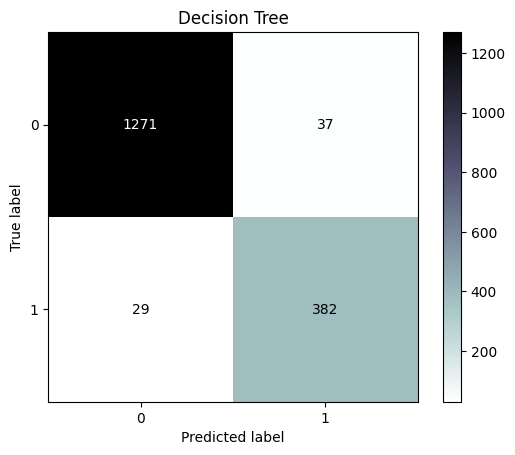

In [15]:
from sklearn.tree import DecisionTreeClassifier
model1=DecisionTreeClassifier()
score1, recall1 = evaluer_modele(
    model1,
    X_train, X_test,
    y_train, y_test,
    "Decision Tree"
)

===== Logistic Regression =====
Accuracy : 0.9889470622454916
Recall : 0.975669099756691

Classification Report :
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1308
           1       0.98      0.98      0.98       411

    accuracy                           0.99      1719
   macro avg       0.99      0.98      0.98      1719
weighted avg       0.99      0.99      0.99      1719

Confusion Matrix :



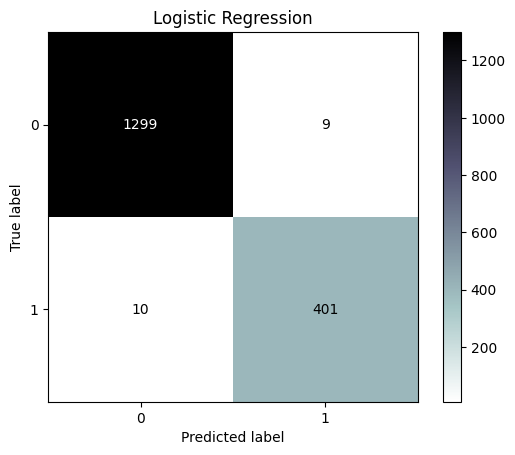

In [16]:
from sklearn.linear_model import LogisticRegression
model2=LogisticRegression(C=1e20)
score2, recall2 = evaluer_modele(
    model2,
    X_train, X_test,
    y_train, y_test,
    "Logistic Regression"
)

===== KNN =====
Accuracy : 0.8708551483420593
Recall : 0.5012165450121655

Classification Report :
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      1308
           1       0.92      0.50      0.65       411

    accuracy                           0.87      1719
   macro avg       0.89      0.74      0.79      1719
weighted avg       0.88      0.87      0.86      1719

Confusion Matrix :



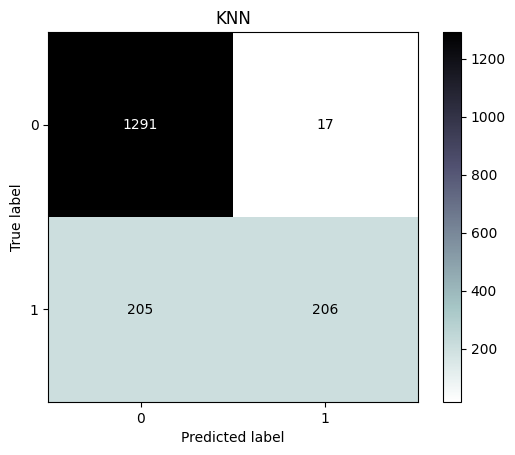

In [17]:
from sklearn.neighbors import KNeighborsClassifier
model3=KNeighborsClassifier(n_neighbors=10,metric='euclidean')
score3, recall3= evaluer_modele(
    model3,
    X_train, X_test,
    y_train, y_test,
    "KNN"
)

===== SVM =====
Accuracy : 0.9796393251890634
Recall : 0.9391727493917275

Classification Report :
              precision    recall  f1-score   support

           0       0.98      0.99      0.99      1308
           1       0.97      0.94      0.96       411

    accuracy                           0.98      1719
   macro avg       0.98      0.97      0.97      1719
weighted avg       0.98      0.98      0.98      1719

Confusion Matrix :



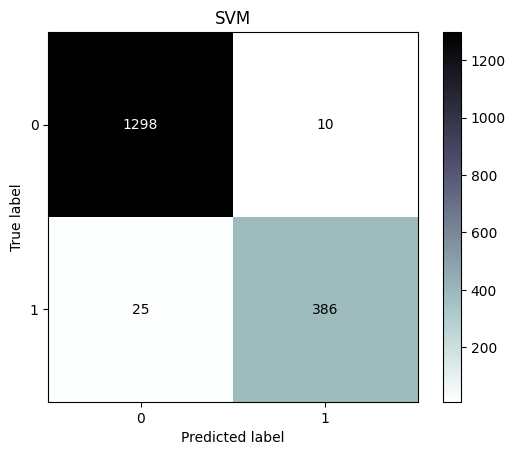

In [18]:
from sklearn.svm import SVC
model4=SVC()
score4, recall4= evaluer_modele(
    model4,
    X_train, X_test,
    y_train, y_test,
    "SVM"
)

===== XGBoost =====
Accuracy : 0.9860383944153578
Recall : 0.9902676399026764

Classification Report :
              precision    recall  f1-score   support

           0       1.00      0.98      0.99      1308
           1       0.95      0.99      0.97       411

    accuracy                           0.99      1719
   macro avg       0.98      0.99      0.98      1719
weighted avg       0.99      0.99      0.99      1719

Confusion Matrix :



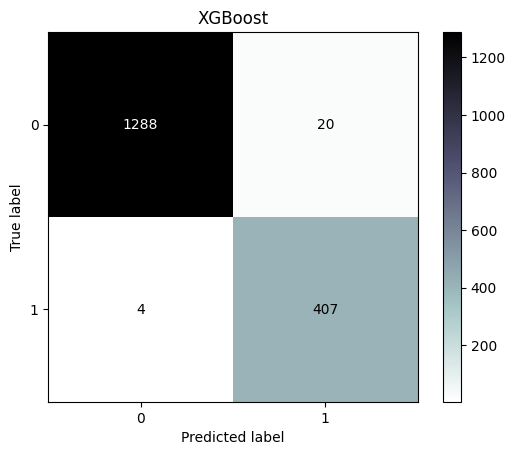

In [19]:
from xgboost import XGBClassifier
model5=XGBClassifier(max_depth=10, learning_rate=0.2)
score5, recall5= evaluer_modele(
    model5,
    X_train, X_test,
    y_train, y_test,
    "XGBoost"
)

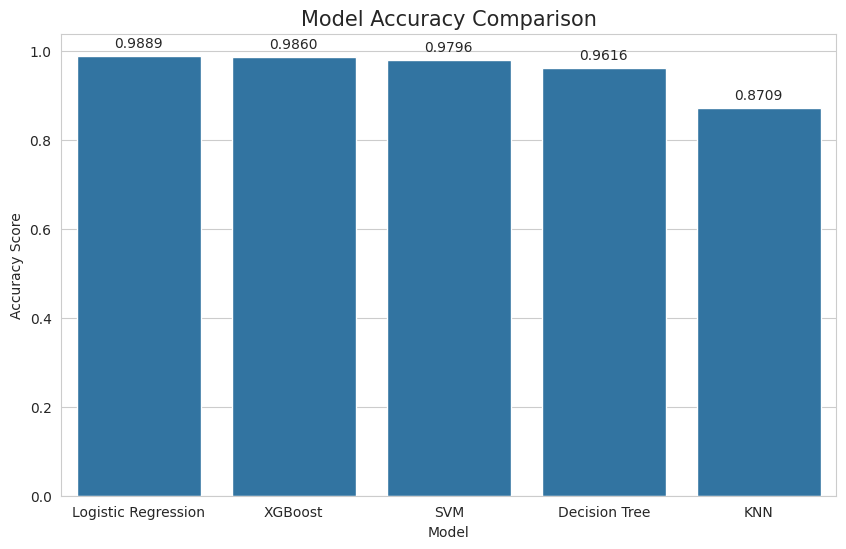

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

results = {
    "Decision Tree": score1,
    "Logistic Regression": score2,
    "KNN": score3,
    "SVM": score4,
    "XGBoost": score5
}

df_results = pd.DataFrame(list(results.items()), columns=['Modèle', 'Accuracy'])
df_results = df_results.sort_values(by='Accuracy', ascending=False)

plt.figure(figsize=(10, 6))
sns.set_style("whitegrid")
ax = sns.barplot(x='Modèle', y='Accuracy', data=df_results)

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title('Model Accuracy Comparison', fontsize=15)
plt.ylabel('Accuracy Score')
plt.xlabel('Model')
plt.show()

## 7. Conclusion and Future Improvements

The current model achieves an impressive accuracy of over **98%**. This demonstrates that simple machine learning algorithms combined with effective text preprocessing can be highly efficient for spam detection.

To further enhance the performance and robustness of this classifier, we could:
1.  **Switch to TF-IDF Vectorizer**: Replace `CountVectorizer` with `TfidfVectorizer` to downscale the importance of very frequent words that carry little information.
2.  **Implement Lemmatization**: Use WordNet or Spacy to group different forms of the same word (e.g., "winning" and "win") to reduce the feature space.
3.  **Explore Deep Learning**: Utilize advanced architectures like **LSTMs** or **BERT** (Transformers) to capture the long-range context and semantic meaning of the sentences.

## Final Words

Thank you for taking the time to explore this notebook! If you found this helpful, please consider **upvoting** it. Feel free to leave a comment if you have any questions or suggestions for improvement!
